# Day 4 - Week 5: Visualization & Anomaly Detection

### Importing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_csv('../day3/data/cardio_patients_raw.csv')
cols = [
    'age',
    'resting_bp',
    'cholesterol',
    'bmi',
    'fasting_blood_sugar',
    'max_heart_rate'
]

X = df[cols].copy()

print("Dataset shape:", X.shape)

X.head()

Dataset shape: (1215, 6)


,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate
0,34.0,155.5,200.5,32.1,1,141.6
1,73.0,117.0,224.7,32.2,1,117.0
2,66.0,131.5,287.9,29.5,1,138.9
3,54.0,109.5,159.0,21.5,0,145.0
4,54.0,115.5,206.2,21.6,0,156.0


In [4]:
cols_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled = cols_preprocess.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (1215, 6)


In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels

print("K-Means cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means cluster counts:
0    521
1    440
2    254
Name: count, dtype: int64


#### Step 1: Apply t-SNE to reduce a high-dimensional dataset to 2D and plot it, coloring by cluster from Day 1 - 2

In [6]:
perplexity = min(30, len(X_scaled) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE output shape:", X_tsne.shape)
print("Perplexity used:", perplexity)

t-SNE output shape: (1215, 2)
Perplexity used: 30


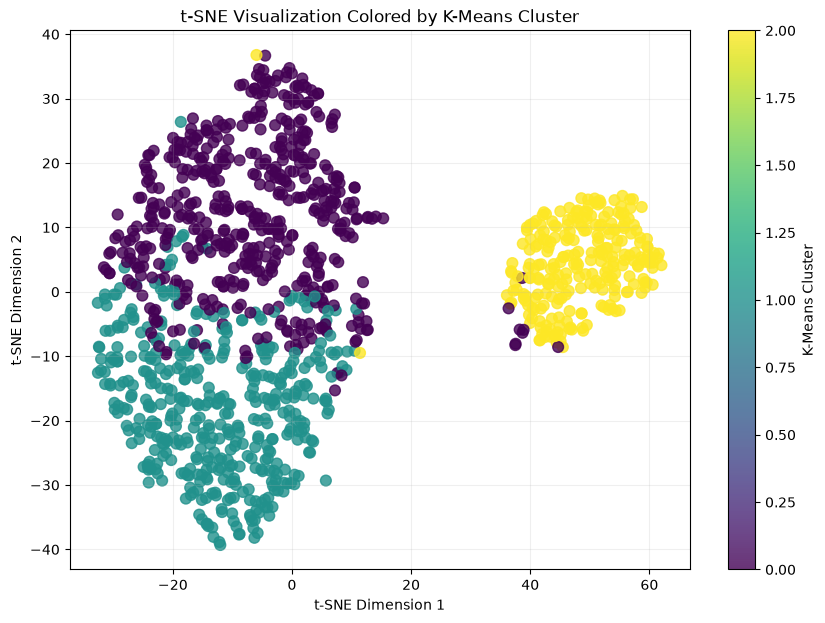

In [7]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.8,
    s=60
)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization Colored by K-Means Cluster')

plt.colorbar(scatter, label='K-Means Cluster')

plt.grid(alpha=0.2)
plt.show()

## Step 1 — t-SNE Visualization

I applied t-SNE to the standardized dataset to reduce the six numeric features into two dimensions for visualization. The final t-SNE representation has a shape of **(1215, 2)**, meaning that all 1,215 observations are represented using two t-SNE dimensions.

A perplexity value of **30** was used, and the points were colored according to the three K-Means clusters identified previously.

The visualization reveals clear local structure in the data. **Cluster 2 forms a strongly separated group on the right side of the plot**, while Clusters 0 and 1 occupy the larger region on the left. Clusters 0 and 1 also show substantial local grouping, although some overlap occurs near their boundary.

This suggests that the K-Means clusters correspond to meaningful local patterns in the original high-dimensional feature space. The particularly strong separation of Cluster 2 indicates that its observations have feature combinations that are noticeably different from those of the other two clusters.

It is important to note that the t-SNE axes themselves do not have a direct interpretation. The main information provided by the plot is the relative neighborhood and grouping of observations rather than the numerical values of the two axes.

#### Step 2: Compare the t-SNE plot to the PCA plot from Day 3 and note what each reveals.

In [8]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

PCA output shape: (1215, 2)
Explained variance ratio: [0.33370126 0.17833429]
Total explained variance: 0.5120355497762065


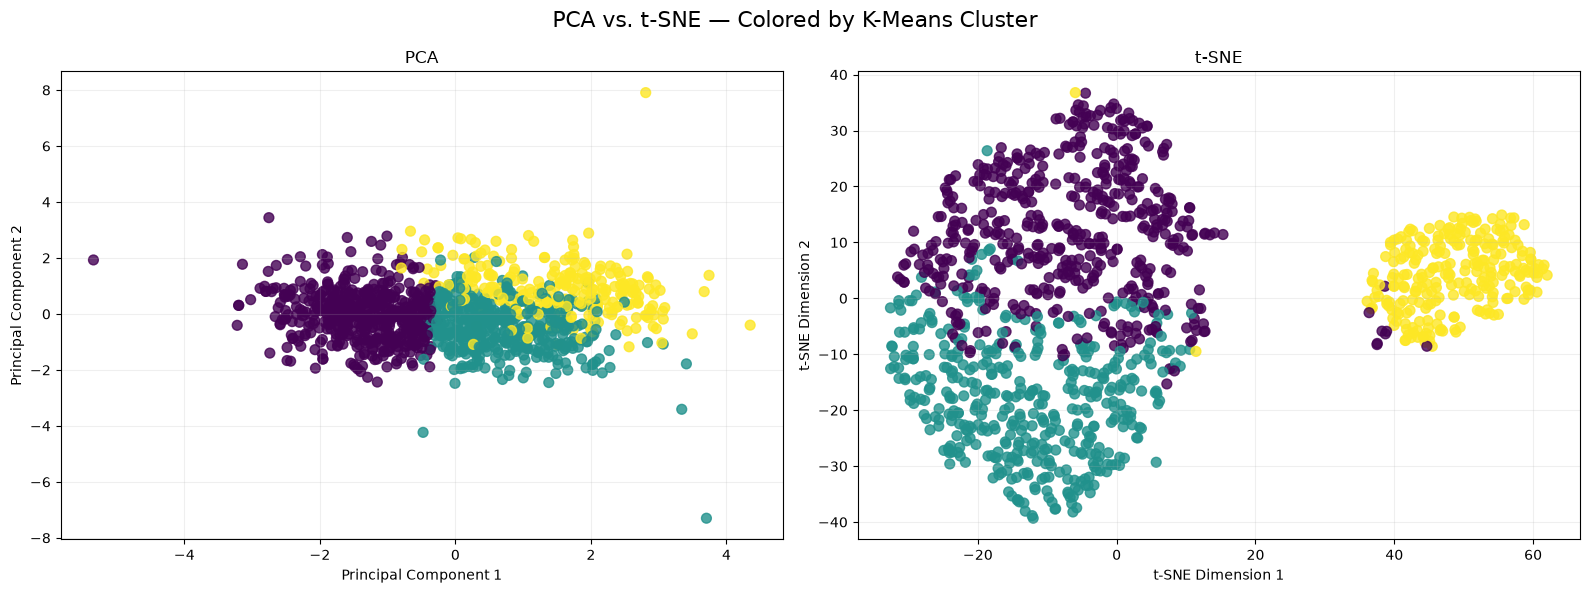

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.8,
    s=50
)

axes[0].set_title('PCA')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(alpha=0.2)

axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.8,
    s=50
)

axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(alpha=0.2)

plt.suptitle(
    'PCA vs. t-SNE — Colored by K-Means Cluster',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 2 — PCA vs. t-SNE Comparison

The PCA and t-SNE visualizations reveal different aspects of the structure in the dataset.

In the **PCA projection**, the three K-Means clusters can be partially distinguished, mainly along the first principal component. However, there is considerable overlap between the clusters, particularly around the center of the plot. PCA provides a compact linear representation of the dataset while attempting to preserve the largest sources of overall variance.

In contrast, the **t-SNE visualization shows much stronger local separation**. Cluster 2 is clearly separated from the other clusters, forming a distinct group on the right side of the plot. Clusters 0 and 1 also form recognizable regions, although some observations overlap near their boundary.

This difference occurs because PCA and t-SNE optimize different properties of the data. PCA focuses on preserving **global variance using linear combinations of the original features**, while t-SNE focuses on preserving **local neighborhoods and similarities between observations**.

For this dataset, t-SNE provides a clearer visualization of the local cluster structure, while PCA provides a more interpretable and globally oriented dimensionality-reduction representation.

Therefore, PCA is more suitable when dimensionality reduction may also be used for further analysis or modeling, whereas t-SNE is particularly useful for visually exploring hidden local structure and cluster separation.

#### Step 3: Run Isolation Forest on the dataset and report how many points were flagged as anomalies.


In [13]:
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_predictions = iso_forest.fit_predict(X_scaled)

df['anomaly'] = anomaly_predictions

In [14]:
n_normal = np.sum(anomaly_predictions == 1)
n_anomalies = np.sum(anomaly_predictions == -1)

print("Isolation Forest Results")
print("-" * 35)

print(f"Normal points: {n_normal}")
print(f"Anomalies: {n_anomalies}")

print(
    f"Anomaly percentage: "
    f"{n_anomalies / len(df) * 100:.2f}%"
)

Isolation Forest Results
-----------------------------------
Normal points: 1154
Anomalies: 61
Anomaly percentage: 5.02%


## Anomaly Scores

Isolation Forest can also assign an anomaly score to each observation.

Lower decision-function values indicate observations that are considered more unusual.

I store this score so that the detected anomalies can be inspected in greater detail.


In [16]:
df['anomaly_score'] = iso_forest.decision_function(X_scaled)

df[
cols +
    ['anomaly', 'anomaly_score']
].head()

,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate,anomaly,anomaly_score
0,34.0,155.5,200.5,32.1,1,141.6,-1,-0.023164
1,73.0,117.0,224.7,32.2,1,117.0,1,0.046885
2,66.0,131.5,287.9,29.5,1,138.9,1,0.043169
3,54.0,109.5,159.0,21.5,0,145.0,1,0.095301
4,54.0,115.5,206.2,21.6,0,156.0,1,0.124394


In [18]:
anomalies = df[df['anomaly'] == -1].copy()

print("Detected anomalies:", len(anomalies))

anomalies[
    cols +
    ['anomaly_score']
].sort_values('anomaly_score')

Detected anomalies: 61


,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate,anomaly_score
888,30.0,118.1,105.3,32.1,1,195.9,-0.132430
622,39.0,121.6,148.1,26.7,1,195.7,-0.082071
775,83.0,NaN,331.3,35.4,1,110.2,-0.055062
796,84.0,104.2,252.5,20.5,1,120.8,-0.049672
1103,38.0,100.6,207.7,NaN,1,171.5,-0.047146
...,...,...,...,...,...,...,...
827,80.0,141.3,290.8,22.0,1,124.1,-0.002766
808,51.0,112.2,250.0,27.6,1,161.4,-0.001438
631,48.0,142.3,173.5,35.3,1,153.8,-0.000804
94,80.0,NaN,186.0,26.2,1,90.9,-0.000790


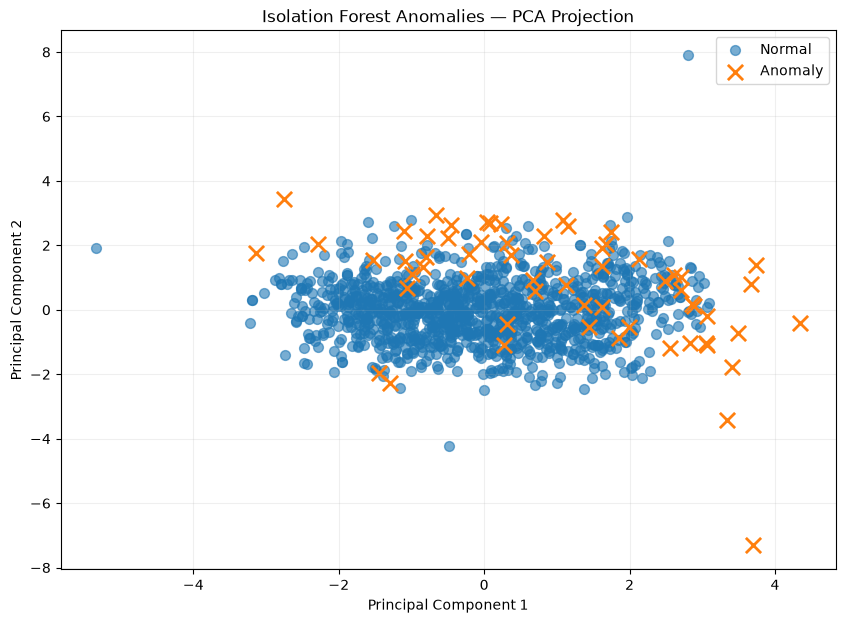

In [19]:
plt.figure(figsize=(10, 7))

normal_mask = anomaly_predictions == 1
anomaly_mask = anomaly_predictions == -1

plt.scatter(
    X_pca[normal_mask, 0],
    X_pca[normal_mask, 1],
    alpha=0.6,
    label='Normal',
    s=50
)

plt.scatter(
    X_pca[anomaly_mask, 0],
    X_pca[anomaly_mask, 1],
    marker='x',
    s=120,
    linewidth=2,
    label='Anomaly'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('Isolation Forest Anomalies — PCA Projection')

plt.legend()

plt.grid(alpha=0.2)

plt.show()

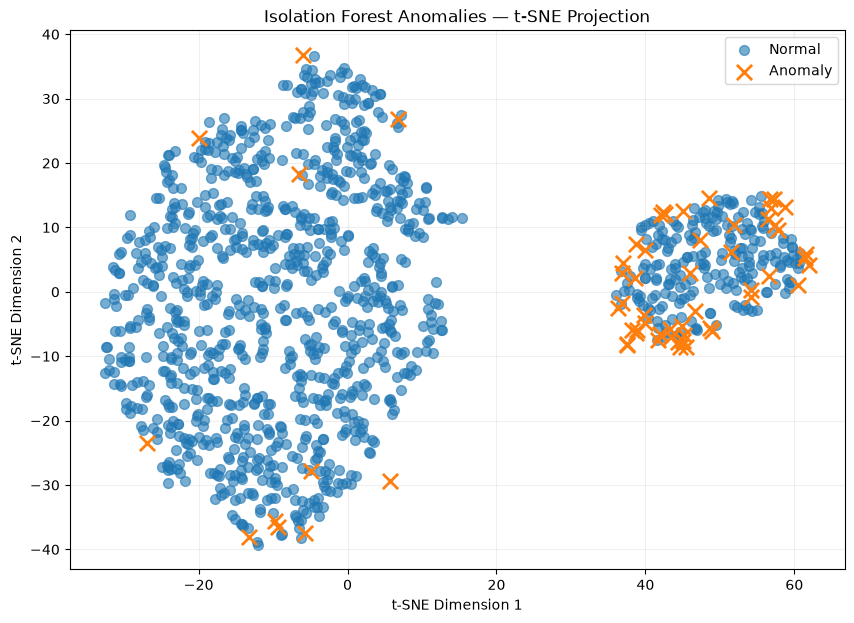

In [20]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[normal_mask, 0],
    X_tsne[normal_mask, 1],
    alpha=0.6,
    label='Normal',
    s=50
)

plt.scatter(
    X_tsne[anomaly_mask, 0],
    X_tsne[anomaly_mask, 1],
    marker='x',
    s=120,
    linewidth=2,
    label='Anomaly'
)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.title('Isolation Forest Anomalies — t-SNE Projection')

plt.legend()

plt.grid(alpha=0.2)

plt.show()

## Step 3 — Isolation Forest Anomaly Detection

I applied Isolation Forest to the same standardized feature set using a contamination value of **0.05**. This parameter indicates that approximately 5% of the observations are expected to behave unusually compared with the majority of the dataset.

The Isolation Forest produced the following results:

- **Total observations:** 1,215
- **Normal observations:** 1,154
- **Flagged anomalies:** 61
- **Percentage flagged as anomalies:** 5.02%

The detected anomaly percentage is therefore very close to the expected 5% contamination level.

The PCA and t-SNE anomaly visualizations show that many flagged observations occur around the outer regions of the data distribution. However, some anomalies also appear relatively close to other observations in the two-dimensional projections.

This is expected because Isolation Forest performs anomaly detection using the full multidimensional feature space rather than only the two dimensions shown in PCA or t-SNE. A point that does not appear visually extreme in a 2D projection may still contain an unusual combination of values across the original features.

The detected points should therefore be interpreted as observations with unusual multivariate feature patterns rather than automatically being considered errors or invalid records.

#### Step 4: Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.


In [22]:
two_strongest_anomalies = (
    df[df['anomaly'] == -1]
    .sort_values('anomaly_score')
    .head(2)
)

two_strongest_anomalies[
    cols +
    ['anomaly_score']
]

,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate,anomaly_score
888,30.0,118.1,105.3,32.1,1,195.9,-0.132430
622,39.0,121.6,148.1,26.7,1,195.7,-0.082071


In [24]:
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1215.0,57.692181,16.405560,7.0,43.000,58.0,72.000,150.0
resting_bp,1184.0,127.983193,16.865876,25.0,117.575,128.2,138.825,310.0
cholesterol,1185.0,210.092152,43.057011,-15.0,182.700,208.7,234.600,850.0
bmi,1185.0,27.238481,4.493192,7.0,24.300,27.3,30.000,75.0
fasting_blood_sugar,1215.0,0.214815,0.410863,0.0,0.000,0.0,0.000,1.0
max_heart_rate,1183.0,139.346830,17.698487,35.0,127.600,138.8,150.800,290.0


In [25]:
feature_means = df[cols].mean()
feature_stds = df[cols].std()

anomaly_z_scores = (
    two_strongest_anomalies[cols] - feature_means
) / feature_stds

anomaly_z_scores

,age,resting_bp,cholesterol,bmi,fasting_blood_sugar,max_heart_rate
888,-1.687975,-0.585988,-2.433800,1.081975,1.911064,3.195367
622,-1.139381,-0.378468,-1.439769,-0.119844,1.911064,3.184067


In [26]:
for index, row in anomaly_z_scores.iterrows():

    print(f"\nObservation index: {index}")
    print("-" * 40)

    unusual_features = (
        row.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    for feature in unusual_features.index:

        actual_value = df.loc[index, feature]
        z_score = row[feature]

        print(
            f"{feature}: "
            f"value = {actual_value}, "
            f"z-score = {z_score:.2f}"
        )


Observation index: 888
----------------------------------------
max_heart_rate: value = 195.9, z-score = 3.20
cholesterol: value = 105.3, z-score = -2.43
fasting_blood_sugar: value = 1, z-score = 1.91

Observation index: 622
----------------------------------------
max_heart_rate: value = 195.7, z-score = 3.18
fasting_blood_sugar: value = 1, z-score = 1.91
cholesterol: value = 148.1, z-score = -1.44


## Step 4 — Inspection of Two Flagged Anomalies

To better understand the Isolation Forest results, I inspected the two observations with the lowest anomaly scores. These points represent the strongest anomalies detected by the model.

### Observation 888

Observation 888 received the lowest anomaly score in the dataset:

**Anomaly score: -0.1324**

Its feature values include:

- Age: **30 years**
- Resting blood pressure: **118.1**
- Cholesterol: **105.3**
- BMI: **32.1**
- Fasting blood sugar indicator: **1**
- Maximum heart rate: **195.9**

The standardized feature values provide useful evidence for why this observation may have been flagged.

The most unusual feature is **maximum heart rate**, with a z-score of approximately **+3.20**. This means that the value is more than three standard deviations above the dataset mean and is therefore highly unusual relative to most observations.

The cholesterol value is also unusual, with a z-score of approximately **-2.43**, meaning that it is substantially below the dataset average. The fasting blood sugar indicator also corresponds to a less common pattern in the dataset, while the age is below average with a z-score of approximately **-1.69**.

Therefore, Observation 888 was likely flagged not because of one feature alone, but because of the unusual combination of a very high maximum heart rate, low cholesterol, younger age, and the fasting blood sugar indicator.

---

### Observation 622

Observation 622 received the second-lowest anomaly score:

**Anomaly score: -0.0821**

Its feature values are:

- Age: **39 years**
- Resting blood pressure: **121.6**
- Cholesterol: **148.1**
- BMI: **26.7**
- Fasting blood sugar indicator: **1**
- Maximum heart rate: **195.7**

Again, the strongest unusual characteristic is **maximum heart rate**, which has a z-score of approximately **+3.18**. This places the observation more than three standard deviations above the dataset mean for this feature.

The cholesterol value is below average with a z-score of approximately **-1.44**, while age is also below average with a z-score of approximately **-1.14**. The fasting blood sugar indicator represents another relatively uncommon characteristic in the dataset.

Although several of these values are not individually extreme, their combination creates a feature pattern that differs from the majority of observations. Isolation Forest detects this type of multivariate unusual behavior, which likely explains why Observation 622 was flagged.

---

### Interpretation

Both of the strongest anomalies share an important characteristic: an unusually high **maximum heart rate**, with values close to 196 and z-scores greater than +3.

They also combine this high maximum heart rate with below-average cholesterol values and the same fasting blood sugar indicator. Observation 888 shows the stronger overall anomaly pattern because its cholesterol level is considerably more extreme and its anomaly score is lower.

These results demonstrate that Isolation Forest does not simply search for one extreme feature. Instead, it evaluates the overall combination of features and identifies observations that can be isolated more easily from the majority of the data.

The flagged observations should be interpreted as **statistically unusual data points**, not as medical diagnoses. They may represent rare but valid combinations of measurements or observations that would require further investigation.